# What is Maximum Common Substructure (MCS)?

The Maximum Common Substructure (MCS) is the largest substructure shared by two or more molecules.

It identifies the common structural core while ignoring the parts that differ between molecules.

MCS analysis helps researchers understand structural relationships among compounds and identify conserved chemical motifs.

## Why Do We Need MCS?

Many molecules in drug discovery differ only by small structural modifications.

Finding their common core helps researchers:

- Compare related molecules
- Identify conserved scaffolds
- Study structure–activity relationships (SAR)
- Support lead optimization
- Group molecules into chemical families

# Example

In [1]:
# Import Libraries
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdFMCS

In [2]:
# Create Two Molecules

aspirin = Chem.MolFromSmiles(
    "CC(=O)Oc1ccccc1C(=O)O"
)

salicylic = Chem.MolFromSmiles(
    "Oc1ccccc1C(=O)O"
)

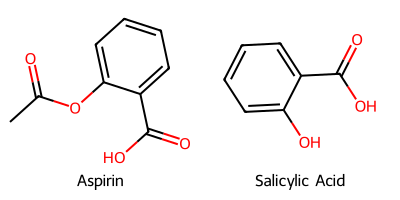

In [3]:
# Display Both Molecules

Draw.MolsToGridImage(
    [aspirin, salicylic],
    legends=["Aspirin", "Salicylic Acid"],
    molsPerRow=2
)

In [4]:
# Find the MCS

mcs = rdFMCS.FindMCS([aspirin, salicylic])

print(mcs.smartsString)


[#8]-[#6]1:[#6]:[#6]:[#6]:[#6]:[#6]:1-[#6](=[#8])-[#8]


In [5]:
# Convert the SMARTS to a Molecule

mcs_mol = Chem.MolFromSmarts(
    mcs.smartsString
)

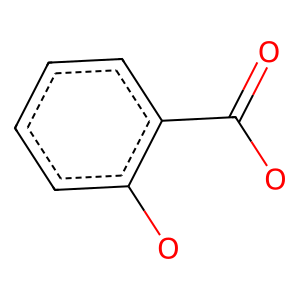

In [6]:
# Display the MCS

Draw.MolToImage(
    mcs_mol,
    size=(300,300)
)

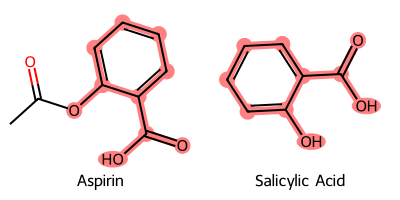

In [7]:
# Highlight the MCS

match1 = aspirin.GetSubstructMatch(mcs_mol)

match2 = salicylic.GetSubstructMatch(mcs_mol)

Draw.MolsToGridImage(
    [aspirin, salicylic],
    highlightAtomLists=[match1, match2],
    legends=["Aspirin", "Salicylic Acid"],
    molsPerRow=2
)

## Interpretation

The Maximum Common Substructure (MCS) analysis identified the largest structural fragment shared by Aspirin and Salicylic Acid.

The highlighted atoms represent the conserved chemical core present in both molecules.

Unlike Murcko scaffold analysis, which extracts the scaffold from a single molecule, MCS directly compares multiple molecules and retains only the atoms and bonds common to all of them.

MCS analysis is widely used in medicinal chemistry to compare related compounds, identify conserved motifs, and support structure–activity relationship (SAR) studies.

# Example 2

In [8]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdFMCS

drugs = {
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O",
    "Naproxen": "COc1ccc2cc([C@H](C)C(=O)O)ccc2c1",
    "Diclofenac": "O=C(O)Cc1ccccc1Nc2c(Cl)cccc2Cl"
}

molecules = [Chem.MolFromSmiles(smiles) for smiles in drugs.values()]

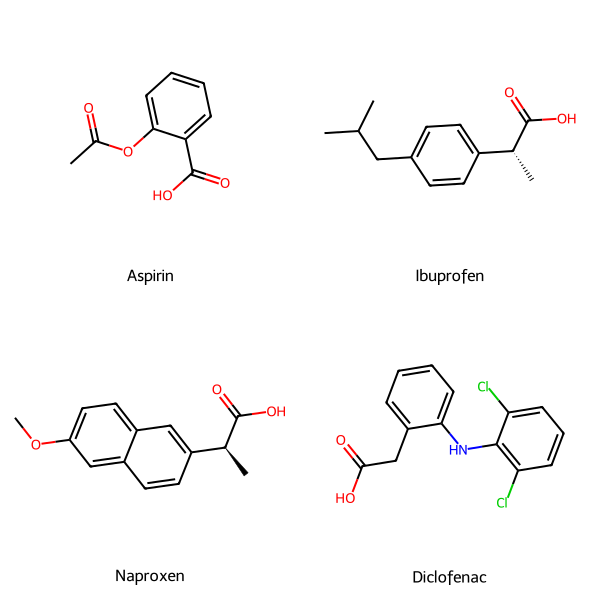

In [9]:
# Display the molecules

Draw.MolsToGridImage(
    molecules,
    legends=list(drugs.keys()),
    molsPerRow=2,
    subImgSize=(300,300)
)

In [10]:
# Find the Maximum Common Substructure

mcs = rdFMCS.FindMCS(molecules)

print("SMARTS:")
print(mcs.smartsString)

SMARTS:
[#6](:[#6]:[#6]:[#6]:,-[#6]):,-[#6]-[#6](=[#8])-[#8]


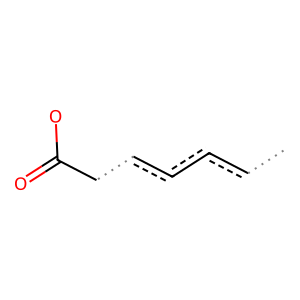

In [11]:
# Convert SMARTS to a Molecules

mcs_mol = Chem.MolFromSmarts(mcs.smartsString)

Draw.MolToImage(
    mcs_mol,
    size=(300,300)
)

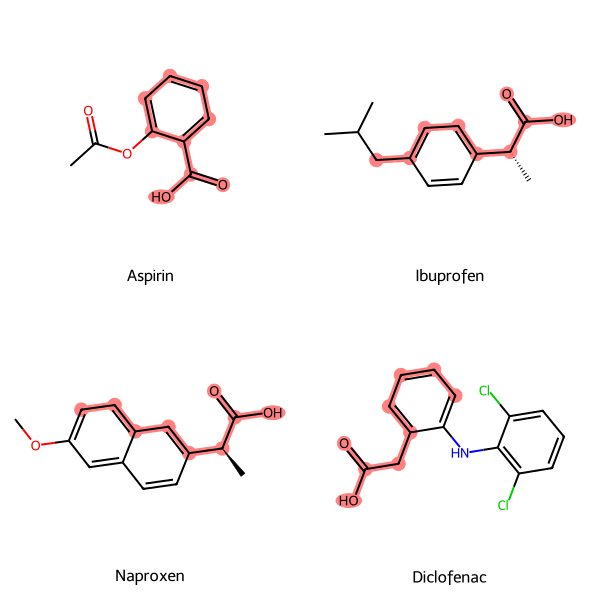

In [12]:
# Highlight the MCS in each Drug

matches = []

for mol in molecules:
    matches.append(
        mol.GetSubstructMatch(mcs_mol)
    )

Draw.MolsToGridImage(
    molecules,
    legends=list(drugs.keys()),
    highlightAtomLists=matches,
    molsPerRow=2,
    subImgSize=(300,300)
)

The Maximum Common Substructure among the four NSAID drugs is smaller than that observed between Aspirin and Salicylic Acid.

Although all four compounds belong to the NSAID class, they possess different chemical scaffolds.

The MCS therefore represents only the structural fragment conserved across all molecules, while the remaining regions reflect structural diversity introduced during medicinal chemistry optimization.

This illustrates that drugs with similar biological activity do not necessarily share the same scaffold, but they often retain smaller common structural motifs.